--2026-03-25 03:40:13--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 91814 (90K) [image/jpeg]
Saving to: ‘imagen_test.jpg’

imagen_test.jpg     100%[===================>]  89.66K  --.-KB/s    in 0.01s   

2026-03-25 03:40:13 (6.01 MB/s) - ‘imagen_test.jpg’ saved [91814/91814]



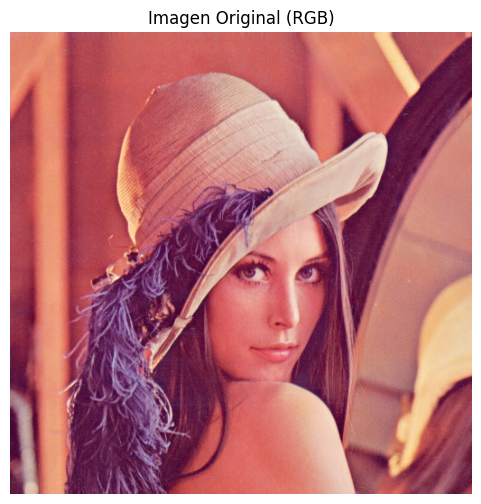

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar una imagen (puedes subir una a Colab o usar una URL)
# Si no tienes una, descargamos una de ejemplo:
!wget -O imagen_test.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg

img_bgr = cv2.imread('imagen_test.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Mostrar imagen original
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Imagen Original (RGB)")
plt.axis('off')
plt.show()

Canales HSV: Matiz (Hue), Saturación (S), Valor (V)


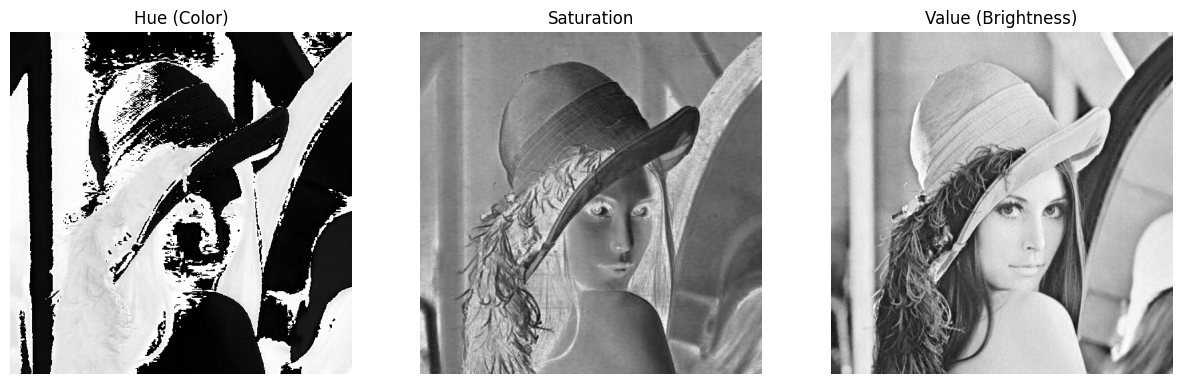

Canales CIE Lab: Luminosidad (L), Canal A (Verde-Rojo), Canal B (Azul-Amarillo)


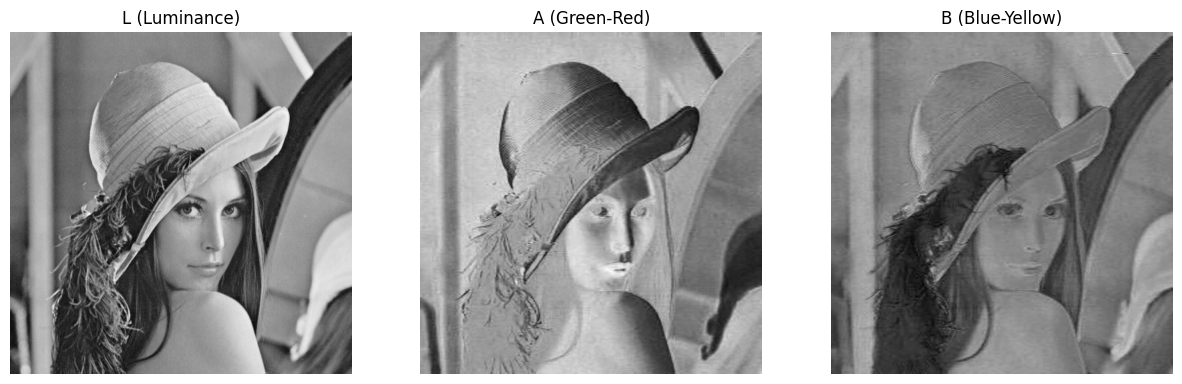

In [2]:
# Convertir a HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Convertir a CIE Lab
img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2Lab)

# Función para visualizar canales
def plot_channels(img, titles, cmap=None):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    for i in range(3):
        axs[i].imshow(img[:,:,i], cmap=cmap if cmap else 'gray')
        axs[i].set_title(titles[i])
        axs[i].axis('off')
    plt.show()

print("Canales HSV: Matiz (Hue), Saturación (S), Valor (V)")
plot_channels(img_hsv, ["Hue (Color)", "Saturation", "Value (Brightness)"])

print("Canales CIE Lab: Luminosidad (L), Canal A (Verde-Rojo), Canal B (Azul-Amarillo)")
plot_channels(img_lab, ["L (Luminance)", "A (Green-Red)", "B (Blue-Yellow)"])

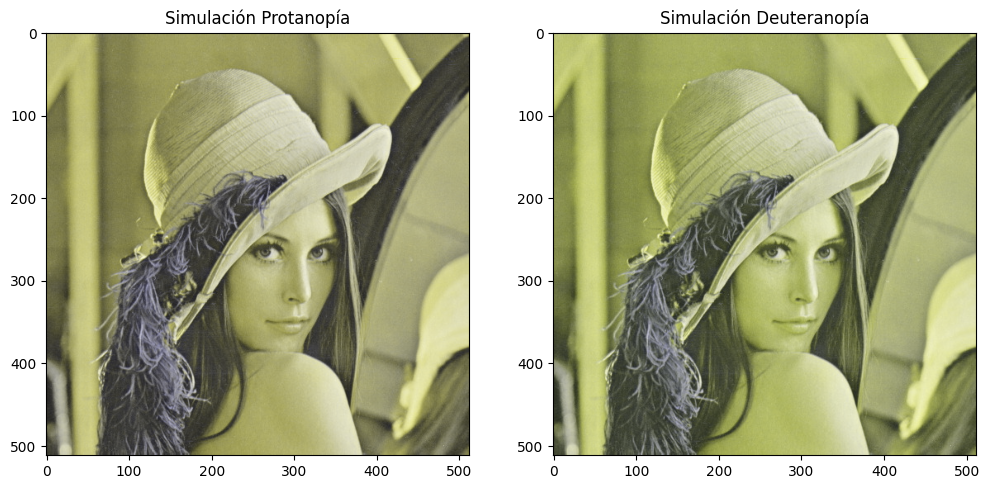

In [3]:
def simular_daltonismo(img, tipo='protanopia'):
    # Matrices de transformación simplificadas
    matrices = {
        'protanopia': np.array([
            [0.567, 0.433, 0.0],
            [0.558, 0.442, 0.0],
            [0.0, 0.242, 0.758]
        ]),
        'deuteranopia': np.array([
            [0.625, 0.375, 0.0],
            [0.7, 0.3, 0.0],
            [0.0, 0.3, 0.7]
        ])
    }

    # Aplicar la matriz
    img_sim = img.dot(matrices[tipo].T)
    img_sim = np.clip(img_sim, 0, 255).astype(np.uint8)
    return img_sim

# Visualizar resultados
protan = simular_daltonismo(img_rgb, 'protanopia')
deutan = simular_daltonismo(img_rgb, 'deuteranopia')

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(protan); axs[0].set_title("Simulación Protanopía")
axs[1].imshow(deutan); axs[1].set_title("Simulación Deuteranopía")
plt.show()